CHARGEMENT DU DATASET PeMS-Bay
Dataset chargé avec succès.
Shape complète : (52116, 325)

SOUS-ENSEMBLE UTILISE
Nombre de jours retenus : 120
Nombre de pas retenus   : 34560
Nombre de capteurs      : 325
Horizon choisi          : J+14
Horizon en pas          : 4032
Fenêtre d'entrée        : 12 pas

DECOUPAGE TRAIN / TEST
Train shape : (27648, 325)
Test shape  : (6912, 325)

Normalisation effectuée avec StandardScaler.
La normalisation a été ajustée uniquement sur le jeu d'entraînement.

TAILLE DES JEUX DE DONNEES
Train samples : 23605
Test samples  : 2869

BASELINE NAIVE MULTICAPTEUR A J+14
Naive MAE  (tous les capteurs) : 2.6530
Naive RMSE (tous les capteurs) : 6.0066
Nombre total d'exemples test évalués : 2869

CAPTEURS LES PLUS DIFFICILES (TOP 10 PAR MAE)
   Capteur       MAE       RMSE
0   401457  8.784003   9.358763
1   400209  8.311047  10.042188
2   400970  7.722164  10.552142
3   400372  6.926563  13.201932
4   400709  6.776098   7.902791
5   401555  6.578691  10.999135
6   401

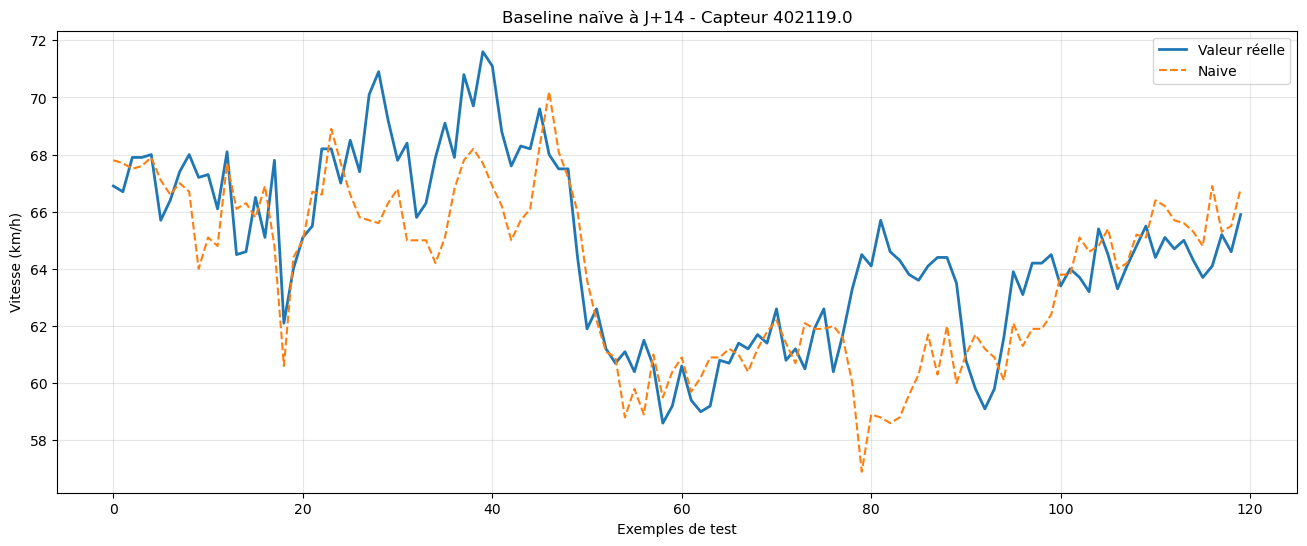

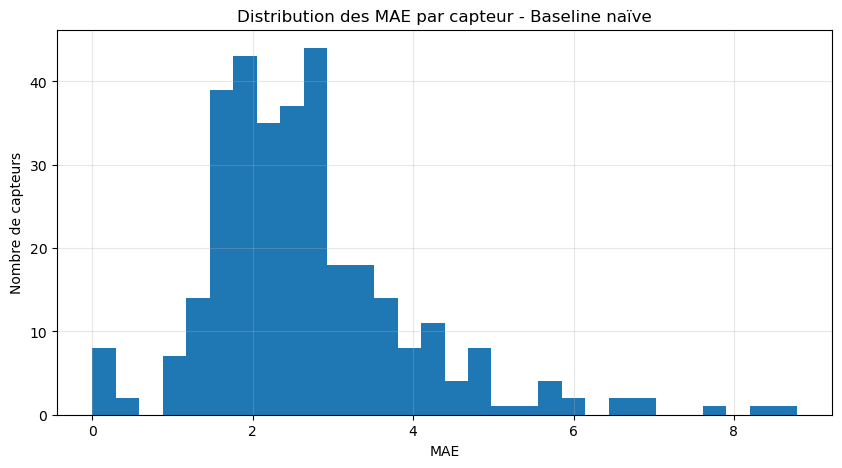

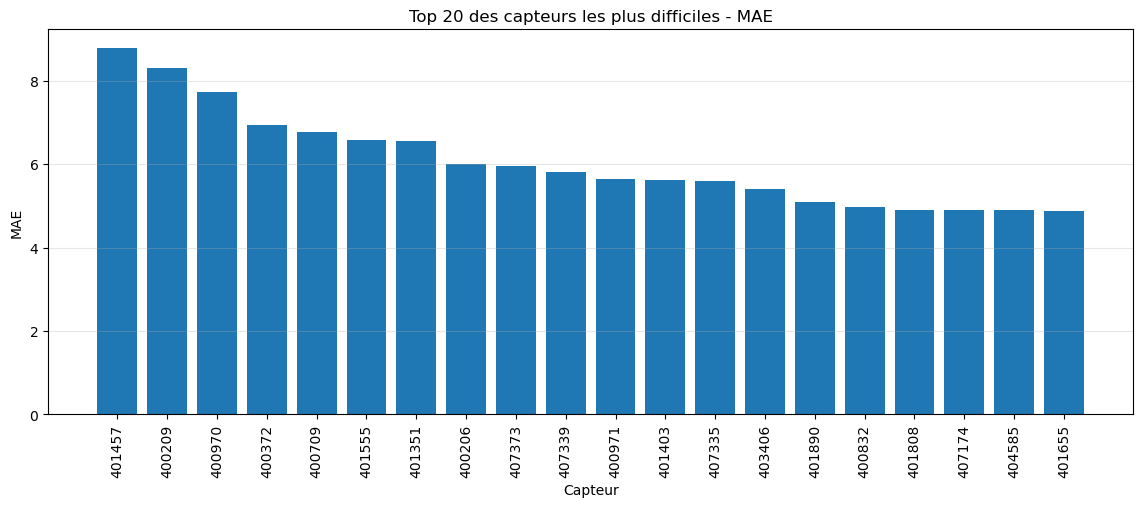


RESUME DE STEP 1
Protocole retenu          : 80% train / 20% test
Objectif principal        : prévision multicapteur à J+14
MAE globale  (325 capteurs) : 2.6530
RMSE globale (325 capteurs) : 6.0066
Capteur illustratif choisi  : 402119.0
Cette baseline servira de référence pour CNN, LSTM et GCN.


In [15]:
# ============================================================
# STEP 1 - PREPARATION MULTICAPTEUR + BASELINE NAIVE A J+14
# PROTOCOLE : 80% TRAIN / 20% TEST
# OBJECTIF : PREDIRE LES 325 CAPTEURS A 14 JOURS D'AVANCE
# DONNEES : 4 MOIS DU DATASET PeMS-Bay
# METRIQUES OFFICIELLES : MAE / RMSE SUR TOUS LES CAPTEURS
# ============================================================

# ------------------------------------------------------------
# 1) IMPORT DES LIBRAIRIES
# ------------------------------------------------------------
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader
import torch

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 2) PARAMETRES GENERAUX
# ------------------------------------------------------------
DATA_DIR = r"C:\Users\ilyas\Desktop\traffic_project\data"
DATA_FILE = os.path.join(DATA_DIR, "pems-bay.h5")

SEED = 42
NB_DAYS_USED = 120              # environ 4 mois
STEPS_PER_DAY = 288             # 24*60/5
WINDOW = 12                     # 12 pas = 1 heure d'historique
HORIZON_DAYS = 14               # objectif principal
HORIZON = HORIZON_DAYS * STEPS_PER_DAY

TRAIN_RATIO = 0.80
TEST_RATIO = 0.20

BATCH_SIZE = 64
NUM_WORKERS = 0
MAX_TEST_BATCHES = 80           # pour accélérer l'évaluation initiale

# ------------------------------------------------------------
# 3) REPRODUCTIBILITE
# ------------------------------------------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# 4) FONCTIONS UTILES
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

class TrafficDataset(Dataset):
    """
    Dataset multicapteur généré à la volée.
    x : fenêtre temporelle de taille WINDOW
    y : vecteur des vitesses futures sur tous les capteurs
    """
    def __init__(self, data_array, window, horizon):
        self.data = data_array.astype(np.float32)
        self.window = window
        self.horizon = horizon
        self.length = len(self.data) - self.window - self.horizon + 1

        if self.length <= 0:
            raise ValueError("Pas assez de données pour créer le dataset.")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window]                # (window, sensors)
        y = self.data[idx + self.window + self.horizon - 1]  # (sensors,)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# ------------------------------------------------------------
# 5) CHARGEMENT DU DATASET
# ------------------------------------------------------------
print("=" * 80)
print("CHARGEMENT DU DATASET PeMS-Bay")
print("=" * 80)

df_full = pd.read_hdf(DATA_FILE)
df_full = df_full.apply(pd.to_numeric, errors="coerce")

if df_full.isna().sum().sum() > 0:
    df_full = df_full.interpolate(method="linear", axis=0).ffill().bfill()

print("Dataset chargé avec succès.")
print("Shape complète :", df_full.shape)

# ------------------------------------------------------------
# 6) SELECTION DES 4 MOIS
# ------------------------------------------------------------
subset_steps = NB_DAYS_USED * STEPS_PER_DAY
subset_steps = min(subset_steps, len(df_full))

df = df_full.iloc[:subset_steps].copy()
values = df.values.astype(np.float32)

n_time, n_sensors = values.shape

print("\n" + "=" * 80)
print("SOUS-ENSEMBLE UTILISE")
print("=" * 80)
print(f"Nombre de jours retenus : {NB_DAYS_USED}")
print(f"Nombre de pas retenus   : {n_time}")
print(f"Nombre de capteurs      : {n_sensors}")
print(f"Horizon choisi          : J+{HORIZON_DAYS}")
print(f"Horizon en pas          : {HORIZON}")
print(f"Fenêtre d'entrée        : {WINDOW} pas")

# ------------------------------------------------------------
# 7) DECOUPAGE TEMPOREL : 80% TRAIN / 20% TEST
# ------------------------------------------------------------
train_end = int(n_time * TRAIN_RATIO)

train_data = values[:train_end]
test_data = values[train_end:]

print("\n" + "=" * 80)
print("DECOUPAGE TRAIN / TEST")
print("=" * 80)
print("Train shape :", train_data.shape)
print("Test shape  :", test_data.shape)

# ------------------------------------------------------------
# 8) NORMALISATION
# ------------------------------------------------------------
scaler = StandardScaler()
scaler.fit(train_data)

train_scaled = scaler.transform(train_data).astype(np.float32)
test_scaled = scaler.transform(test_data).astype(np.float32)

print("\nNormalisation effectuée avec StandardScaler.")
print("La normalisation a été ajustée uniquement sur le jeu d'entraînement.")

# ------------------------------------------------------------
# 9) CONSTRUCTION DES DATASETS ET DATALOADERS
# ------------------------------------------------------------
train_dataset = TrafficDataset(train_scaled, WINDOW, HORIZON)
test_dataset = TrafficDataset(test_scaled, WINDOW, HORIZON)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("\n" + "=" * 80)
print("TAILLE DES JEUX DE DONNEES")
print("=" * 80)
print("Train samples :", len(train_dataset))
print("Test samples  :", len(test_dataset))

# ------------------------------------------------------------
# 10) BASELINE NAIVE MULTICAPTEUR
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("BASELINE NAIVE MULTICAPTEUR A J+14")
print("=" * 80)

all_naive_preds = []
all_true_vals = []

for batch_idx, (xb, yb) in enumerate(test_loader):
    # xb shape : (batch, window, sensors)
    # yb shape : (batch, sensors)

    xb_np = xb.numpy()
    yb_np = yb.numpy()

    # Baseline naïve : la prédiction est la dernière observation de la fenêtre
    pred_naive_scaled = xb_np[:, -1, :]   # (batch, sensors)

    # Retour à l'échelle originale
    pred_naive = scaler.inverse_transform(pred_naive_scaled)
    true_vals = scaler.inverse_transform(yb_np)

    all_naive_preds.append(pred_naive)
    all_true_vals.append(true_vals)

    if (batch_idx + 1) >= MAX_TEST_BATCHES:
        break

all_naive_preds = np.concatenate(all_naive_preds, axis=0)
all_true_vals = np.concatenate(all_true_vals, axis=0)

naive_mae_all = mean_absolute_error(all_true_vals, all_naive_preds)
naive_rmse_all = rmse(all_true_vals.flatten(), all_naive_preds.flatten())

print(f"Naive MAE  (tous les capteurs) : {naive_mae_all:.4f}")
print(f"Naive RMSE (tous les capteurs) : {naive_rmse_all:.4f}")
print(f"Nombre total d'exemples test évalués : {len(all_true_vals)}")

# ------------------------------------------------------------
# 11) ERREUR MOYENNE PAR CAPTEUR
# ------------------------------------------------------------
mae_per_sensor = np.mean(np.abs(all_true_vals - all_naive_preds), axis=0)
rmse_per_sensor = np.sqrt(np.mean((all_true_vals - all_naive_preds) ** 2, axis=0))

sensor_summary = pd.DataFrame({
    "Capteur": df.columns,
    "MAE": mae_per_sensor,
    "RMSE": rmse_per_sensor
}).sort_values(by="MAE", ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("CAPTEURS LES PLUS DIFFICILES (TOP 10 PAR MAE)")
print("=" * 80)
print(sensor_summary.head(10))

# ------------------------------------------------------------
# 12) VISUALISATION D'UN CAPTEUR REPRESENTATIF
# ------------------------------------------------------------
# Choix d'un capteur médian pour une visualisation équilibrée
median_idx = len(sensor_summary) // 2
sensor_to_plot = sensor_summary.iloc[median_idx]["Capteur"]
sensor_col_idx = list(df.columns).index(sensor_to_plot)

y_true_sensor = all_true_vals[:, sensor_col_idx]
y_pred_sensor = all_naive_preds[:, sensor_col_idx]

plt.figure(figsize=(16, 6))
plt.plot(y_true_sensor[:120], label="Valeur réelle", linewidth=2)
plt.plot(y_pred_sensor[:120], label="Naive", linestyle="--")
plt.title(f"Baseline naïve à J+{HORIZON_DAYS} - Capteur {sensor_to_plot}")
plt.xlabel("Exemples de test")
plt.ylabel("Vitesse (km/h)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 13) HISTOGRAMME DES MAE PAR CAPTEUR
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.hist(mae_per_sensor, bins=30)
plt.title("Distribution des MAE par capteur - Baseline naïve")
plt.xlabel("MAE")
plt.ylabel("Nombre de capteurs")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 14) TOP 20 CAPTEURS LES PLUS DIFFICILES
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))
top20 = sensor_summary.head(20).copy()
plt.bar(top20["Capteur"].astype(str), top20["MAE"])
plt.title("Top 20 des capteurs les plus difficiles - MAE")
plt.xlabel("Capteur")
plt.ylabel("MAE")
plt.xticks(rotation=90)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 15) RESUME FINAL
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("RESUME DE STEP 1")
print("=" * 80)
print("Protocole retenu          : 80% train / 20% test")
print("Objectif principal        : prévision multicapteur à J+14")
print(f"MAE globale  (325 capteurs) : {naive_mae_all:.4f}")
print(f"RMSE globale (325 capteurs) : {naive_rmse_all:.4f}")
print(f"Capteur illustratif choisi  : {sensor_to_plot}")
print("Cette baseline servira de référence pour CNN, LSTM et GCN.")

APPAREIL UTILISE : cpu
CHARGEMENT DU DATASET PeMS-Bay
Shape du sous-ensemble : (34560, 325)
Nombre de capteurs     : 325
Fenêtre                : 12
Horizon                : J+14 (4032 pas)

DECOUPAGE TRAIN / TEST
Train shape : (27648, 325)
Test shape  : (6912, 325)

Normalisation effectuée avec StandardScaler.

TAILLE DES DATASETS
Train samples : 23605
Test samples  : 2869

ARCHITECTURE DU MODELE
CNNForecaster(
  (conv_block): Sequential(
    (0): Conv1d(325, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
  )
  (fc_block): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=768, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=325, bias=True)
  )
)

DEBUT DE L'ENTRAINEMENT DU CNN
Epoch 01/12 | Train Loss = 0.404341
Epoch 02/12 | Train Loss = 0.293693
Epoch 03/12 | Train Loss = 0.248285
Epoch 04/12 | Train Loss 

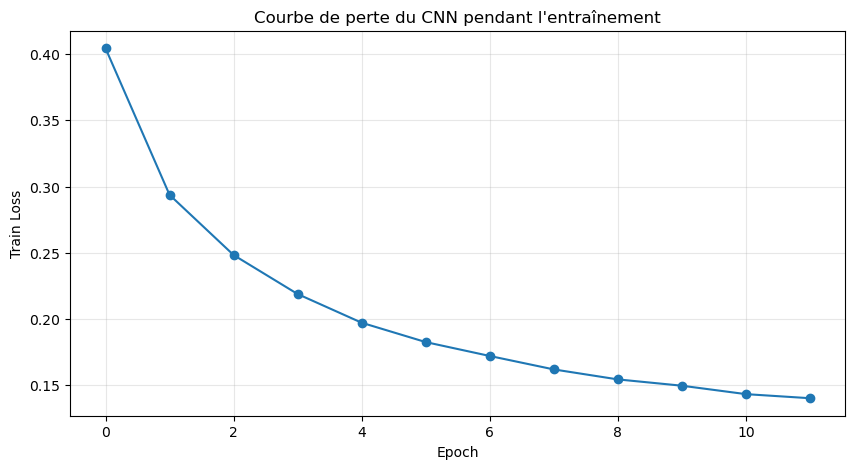

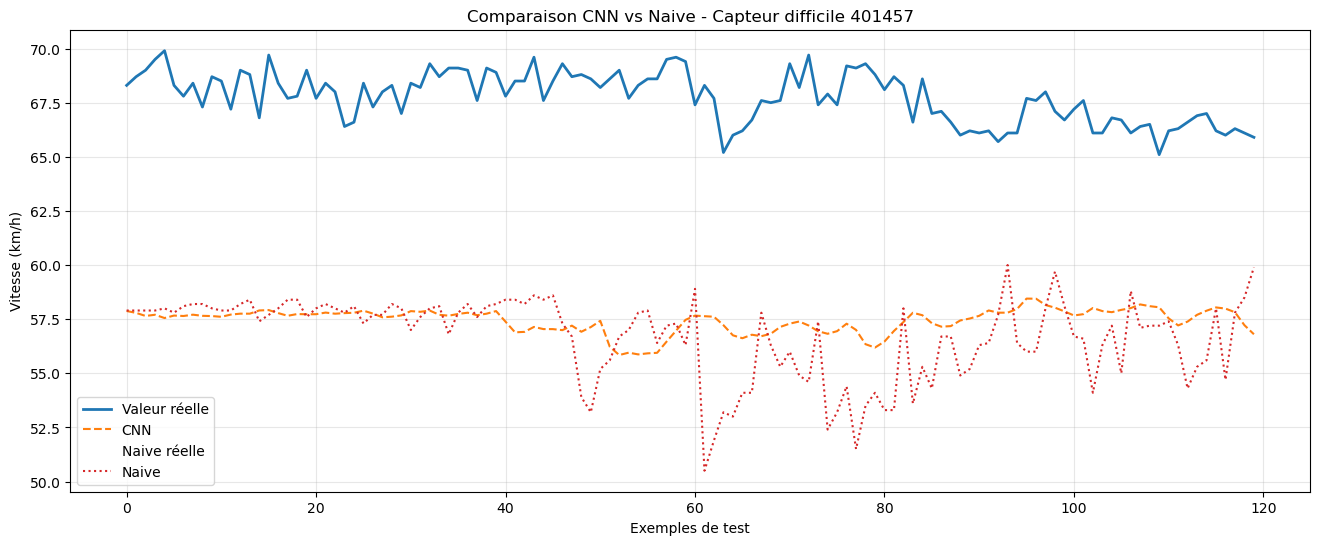

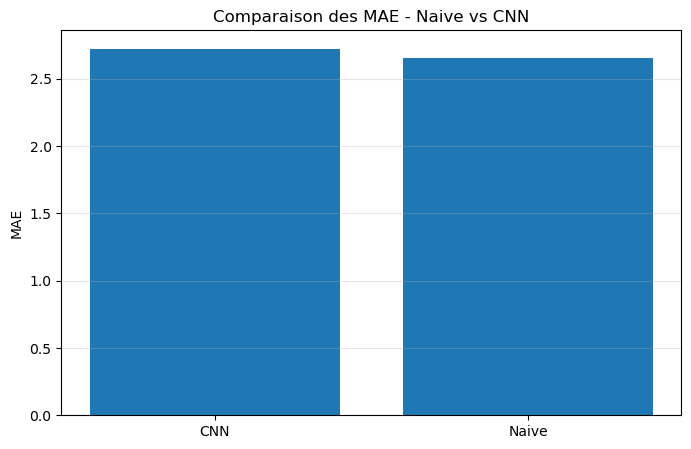

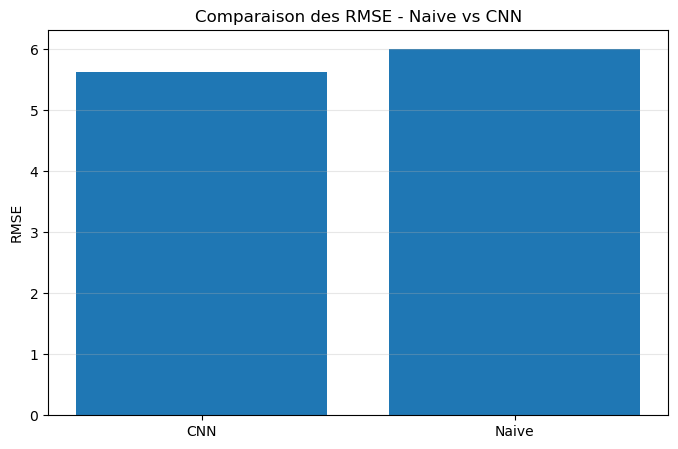


RESUME DE STEP 2
Objectif principal         : prévision multicapteur à J+14
Protocole retenu           : 80% train / 20% test
Naive MAE globale          : 2.6530
Naive RMSE globale         : 6.0066
CNN MAE globale            : 2.7236
CNN RMSE globale           : 5.6205
Capteur difficile illustré : 401457
Le CNN sera ensuite comparé à un modèle LSTM.


In [16]:
# ============================================================
# STEP 2 - CNN MULTICAPTEUR A J+14
# PROTOCOLE : 80% TRAIN / 20% TEST
# OBJECTIF : PREDIRE LES 325 CAPTEURS A 14 JOURS D'AVANCE
# DONNEES : 4 MOIS DU DATASET PeMS-Bay
# METRIQUES OFFICIELLES : MAE / RMSE SUR TOUS LES CAPTEURS
# ============================================================

# ------------------------------------------------------------
# 1) IMPORT DES LIBRAIRIES
# ------------------------------------------------------------
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 2) PARAMETRES GENERAUX
# ------------------------------------------------------------
DATA_DIR = r"C:\Users\ilyas\Desktop\traffic_project\data"
DATA_FILE = os.path.join(DATA_DIR, "pems-bay.h5")

SEED = 42
NB_DAYS_USED = 120              # ~ 4 mois
STEPS_PER_DAY = 288
WINDOW = 12                     # 1 heure d'historique
HORIZON_DAYS = 14
HORIZON = HORIZON_DAYS * STEPS_PER_DAY

TRAIN_RATIO = 0.80
TEST_RATIO = 0.20

BATCH_SIZE = 64
EPOCHS = 12
LEARNING_RATE = 1e-3
NUM_WORKERS = 0
MAX_TEST_BATCHES = 80

# ------------------------------------------------------------
# 3) REPRODUCTIBILITE
# ------------------------------------------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("APPAREIL UTILISE :", device)
print("=" * 80)

# ------------------------------------------------------------
# 4) FONCTIONS UTILES
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

class TrafficDataset(Dataset):
    """
    Dataset multicapteur généré à la volée.
    x : (window, sensors)
    y : (sensors,)
    """
    def __init__(self, data_array, window, horizon):
        self.data = data_array.astype(np.float32)
        self.window = window
        self.horizon = horizon
        self.length = len(self.data) - self.window - self.horizon + 1

        if self.length <= 0:
            raise ValueError("Pas assez de données pour créer le dataset.")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window]
        y = self.data[idx + self.window + self.horizon - 1]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

class CNNForecaster(nn.Module):
    """
    CNN 1D appliqué sur l'axe temporel.
    Les capteurs sont considérés comme canaux d'entrée.
    """
    def __init__(self, n_sensors, window):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=n_sensors, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=128, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * window, 256),
            nn.ReLU(),
            nn.Linear(256, n_sensors)
        )

    def forward(self, x):
        # x : (batch, window, sensors)
        x = x.permute(0, 2, 1)   # -> (batch, sensors, window)
        x = self.conv_block(x)
        x = self.fc_block(x)
        return x

def evaluate_model(model, loader, scaler, device, max_batches=None):
    """
    Evaluation du modèle en revenant à l'échelle originale.
    """
    model.eval()

    all_preds = []
    all_trues = []

    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(loader):
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            pred_np = pred.cpu().numpy()
            y_np = yb.cpu().numpy()

            pred_inv = scaler.inverse_transform(pred_np)
            y_inv = scaler.inverse_transform(y_np)

            all_preds.append(pred_inv)
            all_trues.append(y_inv)

            if max_batches is not None and (batch_idx + 1) >= max_batches:
                break

    all_preds = np.concatenate(all_preds, axis=0)
    all_trues = np.concatenate(all_trues, axis=0)

    mae_value = mean_absolute_error(all_trues, all_preds)
    rmse_value = rmse(all_trues.flatten(), all_preds.flatten())

    return mae_value, rmse_value, all_trues, all_preds

# ------------------------------------------------------------
# 5) CHARGEMENT DU DATASET
# ------------------------------------------------------------
print("=" * 80)
print("CHARGEMENT DU DATASET PeMS-Bay")
print("=" * 80)

df_full = pd.read_hdf(DATA_FILE)
df_full = df_full.apply(pd.to_numeric, errors="coerce")

if df_full.isna().sum().sum() > 0:
    df_full = df_full.interpolate(method="linear", axis=0).ffill().bfill()

subset_steps = NB_DAYS_USED * STEPS_PER_DAY
subset_steps = min(subset_steps, len(df_full))

df = df_full.iloc[:subset_steps].copy()
values = df.values.astype(np.float32)

n_time, n_sensors = values.shape

print("Shape du sous-ensemble :", values.shape)
print(f"Nombre de capteurs     : {n_sensors}")
print(f"Fenêtre                : {WINDOW}")
print(f"Horizon                : J+{HORIZON_DAYS} ({HORIZON} pas)")

# ------------------------------------------------------------
# 6) DECOUPAGE TRAIN / TEST
# ------------------------------------------------------------
train_end = int(n_time * TRAIN_RATIO)

train_data = values[:train_end]
test_data = values[train_end:]

print("\n" + "=" * 80)
print("DECOUPAGE TRAIN / TEST")
print("=" * 80)
print("Train shape :", train_data.shape)
print("Test shape  :", test_data.shape)

# ------------------------------------------------------------
# 7) NORMALISATION
# ------------------------------------------------------------
scaler = StandardScaler()
scaler.fit(train_data)

train_scaled = scaler.transform(train_data).astype(np.float32)
test_scaled = scaler.transform(test_data).astype(np.float32)

print("\nNormalisation effectuée avec StandardScaler.")

# ------------------------------------------------------------
# 8) DATASETS ET DATALOADERS
# ------------------------------------------------------------
train_dataset = TrafficDataset(train_scaled, WINDOW, HORIZON)
test_dataset = TrafficDataset(test_scaled, WINDOW, HORIZON)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("\n" + "=" * 80)
print("TAILLE DES DATASETS")
print("=" * 80)
print("Train samples :", len(train_dataset))
print("Test samples  :", len(test_dataset))

# ------------------------------------------------------------
# 9) DEFINITION DU MODELE
# ------------------------------------------------------------
model = CNNForecaster(n_sensors=n_sensors, window=WINDOW).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\n" + "=" * 80)
print("ARCHITECTURE DU MODELE")
print("=" * 80)
print(model)

# ------------------------------------------------------------
# 10) ENTRAINEMENT
# ------------------------------------------------------------
train_losses = []

print("\n" + "=" * 80)
print("DEBUT DE L'ENTRAINEMENT DU CNN")
print("=" * 80)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss = {epoch_loss:.6f}")

# ------------------------------------------------------------
# 11) EVALUATION DU CNN SUR LE TEST
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("EVALUATION DU CNN SUR LE TEST")
print("=" * 80)

cnn_mae, cnn_rmse, y_true_all, y_pred_all = evaluate_model(
    model=model,
    loader=test_loader,
    scaler=scaler,
    device=device,
    max_batches=MAX_TEST_BATCHES
)

print(f"CNN MAE  (tous les capteurs) : {cnn_mae:.4f}")
print(f"CNN RMSE (tous les capteurs) : {cnn_rmse:.4f}")

# ------------------------------------------------------------
# 12) BASELINE NAIVE SUR LE MEME TEST POUR COMPARAISON
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("COMPARAISON AVEC LA BASELINE NAIVE")
print("=" * 80)

naive_preds = []
naive_trues = []

for batch_idx, (xb, yb) in enumerate(test_loader):
    xb_np = xb.numpy()
    yb_np = yb.numpy()

    pred_naive_scaled = xb_np[:, -1, :]
    pred_naive = scaler.inverse_transform(pred_naive_scaled)
    y_true_inv = scaler.inverse_transform(yb_np)

    naive_preds.append(pred_naive)
    naive_trues.append(y_true_inv)

    if (batch_idx + 1) >= MAX_TEST_BATCHES:
        break

naive_preds = np.concatenate(naive_preds, axis=0)
naive_trues = np.concatenate(naive_trues, axis=0)

naive_mae = mean_absolute_error(naive_trues, naive_preds)
naive_rmse = rmse(naive_trues.flatten(), naive_preds.flatten())

print(f"Naive MAE  (tous les capteurs) : {naive_mae:.4f}")
print(f"Naive RMSE (tous les capteurs) : {naive_rmse:.4f}")

# ------------------------------------------------------------
# 13) TABLEAU RECAPITULATIF
# ------------------------------------------------------------
results_df = pd.DataFrame({
    "Modèle": ["Naive", "CNN"],
    "MAE": [naive_mae, cnn_mae],
    "RMSE": [naive_rmse, cnn_rmse]
}).sort_values(by="RMSE", ascending=True).reset_index(drop=True)

print("\n" + "=" * 80)
print("TABLEAU RECAPITULATIF DES PERFORMANCES")
print("=" * 80)
print(results_df)

# ------------------------------------------------------------
# 14) COURBE D'APPRENTISSAGE
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(train_losses, marker="o")
plt.title("Courbe de perte du CNN pendant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 15) VISUALISATION SUR UN CAPTEUR DIFFICILE
# ------------------------------------------------------------
sensor_errors = np.mean(np.abs(y_true_all - y_pred_all), axis=0)
hard_sensor_idx = int(np.argmax(sensor_errors))
hard_sensor_name = df.columns[hard_sensor_idx]

plt.figure(figsize=(16, 6))
plt.plot(y_true_all[:120, hard_sensor_idx], label="Valeur réelle", linewidth=2)
plt.plot(y_pred_all[:120, hard_sensor_idx], label="CNN", linestyle="--")
plt.plot(naive_trues[:120, hard_sensor_idx], label="Naive réelle", alpha=0.0)  # pour cohérence
plt.plot(naive_preds[:120, hard_sensor_idx], label="Naive", linestyle=":")
plt.title(f"Comparaison CNN vs Naive - Capteur difficile {hard_sensor_name}")
plt.xlabel("Exemples de test")
plt.ylabel("Vitesse (km/h)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 16) COMPARAISON GLOBALE DES MAE ET RMSE
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(results_df["Modèle"], results_df["MAE"])
plt.title("Comparaison des MAE - Naive vs CNN")
plt.ylabel("MAE")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(results_df["Modèle"], results_df["RMSE"])
plt.title("Comparaison des RMSE - Naive vs CNN")
plt.ylabel("RMSE")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 17) RESUME FINAL
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("RESUME DE STEP 2")
print("=" * 80)
print("Objectif principal         : prévision multicapteur à J+14")
print("Protocole retenu           : 80% train / 20% test")
print(f"Naive MAE globale          : {naive_mae:.4f}")
print(f"Naive RMSE globale         : {naive_rmse:.4f}")
print(f"CNN MAE globale            : {cnn_mae:.4f}")
print(f"CNN RMSE globale           : {cnn_rmse:.4f}")
print(f"Capteur difficile illustré : {hard_sensor_name}")
print("Le CNN sera ensuite comparé à un modèle LSTM.")

In [20]:
# ============================================================
# FIGURE COMPLETE - 10 GRAPHIQUES VARIES POUR LE RAPPORT
# OBJECTIF : VISUALISER LE COMPORTEMENT TEMPOREL ET SPATIAL
# DU DATASET PeMS-Bay POUR PREPARER L'ETUDE GCN / GCN+LSTM
# ============================================================

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) PARAMETRES
# ------------------------------------------------------------
DATA_DIR = r"C:\Users\ilyas\Desktop\traffic_project\data"
DATA_FILE = os.path.join(DATA_DIR, "pems-bay.h5")
ADJ_FILE = os.path.join(DATA_DIR, "adj_mx_bay.pkl")

NB_DAYS_USED = 30           # on prend 30 jours pour l'affichage
STEPS_PER_DAY = 288
NB_STEPS = NB_DAYS_USED * STEPS_PER_DAY

# ============================================================
# CHARGEMENT ROBUSTE DE LA MATRICE D'ADJACENCE PeMS-Bay
# ============================================================

import pickle
import numpy as np

print("=" * 60)
print("Chargement de la matrice d'adjacence")
print("=" * 60)

with open(ADJ_FILE, "rb") as f:
    adj_data = pickle.load(f, encoding="latin1")

# Cas 1 : format tuple (cas le plus fréquent pour PeMS-Bay)
if isinstance(adj_data, tuple):

    sensor_ids_graph = adj_data[0]
    sensor_id_to_ind = adj_data[1]
    adj_mx = adj_data[2]

# Cas 2 : format dictionnaire
elif isinstance(adj_data, dict):

    adj_mx = adj_data.get("adj_mx", None)

# Cas 3 : matrice directement
else:

    adj_mx = adj_data

adj_mx = np.array(adj_mx)

print("Matrice d'adjacence chargée avec succès")
print("Shape :", adj_mx.shape)

# ------------------------------------------------------------
# 3) CHOIX DE 10 CAPTEURS REPRESENTATIFS
# ------------------------------------------------------------
sensor_std = df.std(axis=0).sort_values(ascending=False)
selected_sensors = list(sensor_std.head(10).index)

print("Capteurs sélectionnés :")
print(selected_sensors)

# ------------------------------------------------------------
# 4) PREPARATION DES VARIABLES
# ------------------------------------------------------------
mean_speed = df.mean(axis=1)

corr_matrix = df[selected_sensors].corr()

binary_adj = (adj_mx > 0).astype(int)
degrees = binary_adj.sum(axis=1)

# Pour la heatmap temporelle : on réduit un peu la longueur affichée
heatmap_data = df[selected_sensors].iloc[:1000].T.values

# ------------------------------------------------------------
# 5) CREATION DE LA FIGURE MULTI-GRAPHIQUES
# ------------------------------------------------------------
fig, axes = plt.subplots(5, 2, figsize=(18, 24))
fig.suptitle("Exploration visuelle du dataset PeMS-Bay pour GCN / GCN+LSTM", fontsize=18)

# -----------------------------
# Graphique 1
# -----------------------------
axes[0, 0].plot(df[selected_sensors[0]].iloc[:1500])
axes[0, 0].set_title(f"Série temporelle - Capteur {selected_sensors[0]}")
axes[0, 0].set_xlabel("Temps")
axes[0, 0].set_ylabel("Vitesse (km/h)")
axes[0, 0].grid(True, alpha=0.3)

# -----------------------------
# Graphique 2
# -----------------------------
axes[0, 1].plot(df[selected_sensors[1]].iloc[:1500])
axes[0, 1].set_title(f"Série temporelle - Capteur {selected_sensors[1]}")
axes[0, 1].set_xlabel("Temps")
axes[0, 1].set_ylabel("Vitesse (km/h)")
axes[0, 1].grid(True, alpha=0.3)

# -----------------------------
# Graphique 3
# -----------------------------
axes[1, 0].plot(df[selected_sensors[2]].iloc[:1500])
axes[1, 0].set_title(f"Série temporelle - Capteur {selected_sensors[2]}")
axes[1, 0].set_xlabel("Temps")
axes[1, 0].set_ylabel("Vitesse (km/h)")
axes[1, 0].grid(True, alpha=0.3)

# -----------------------------
# Graphique 4
# -----------------------------
axes[1, 1].plot(df[selected_sensors[3]].iloc[:1500])
axes[1, 1].set_title(f"Série temporelle - Capteur {selected_sensors[3]}")
axes[1, 1].set_xlabel("Temps")
axes[1, 1].set_ylabel("Vitesse (km/h)")
axes[1, 1].grid(True, alpha=0.3)

# -----------------------------
# Graphique 5
# -----------------------------
axes[2, 0].plot(df[selected_sensors[4]].iloc[:1500])
axes[2, 0].set_title(f"Série temporelle - Capteur {selected_sensors[4]}")
axes[2, 0].set_xlabel("Temps")
axes[2, 0].set_ylabel("Vitesse (km/h)")
axes[2, 0].grid(True, alpha=0.3)

# -----------------------------
# Graphique 6
# -----------------------------
axes[2, 1].plot(mean_speed.iloc[:1500], color="black")
axes[2, 1].set_title("Vitesse moyenne de l'ensemble du réseau")
axes[2, 1].set_xlabel("Temps")
axes[2, 1].set_ylabel("Vitesse moyenne (km/h)")
axes[2, 1].grid(True, alpha=0.3)

# -----------------------------
# Graphique 7
# -----------------------------
im1 = axes[3, 0].imshow(heatmap_data, aspect="auto")
axes[3, 0].set_title("Heatmap temporelle de 10 capteurs")
axes[3, 0].set_xlabel("Temps")
axes[3, 0].set_ylabel("Capteurs")
axes[3, 0].set_yticks(range(len(selected_sensors)))
axes[3, 0].set_yticklabels(selected_sensors)
fig.colorbar(im1, ax=axes[3, 0], fraction=0.046, pad=0.04)

# -----------------------------
# Graphique 8
# -----------------------------
im2 = axes[3, 1].imshow(corr_matrix, aspect="auto", vmin=-1, vmax=1)
axes[3, 1].set_title("Matrice de corrélation entre 10 capteurs")
axes[3, 1].set_xticks(range(len(selected_sensors)))
axes[3, 1].set_yticks(range(len(selected_sensors)))
axes[3, 1].set_xticklabels(selected_sensors, rotation=90)
axes[3, 1].set_yticklabels(selected_sensors)
fig.colorbar(im2, ax=axes[3, 1], fraction=0.046, pad=0.04)

# -----------------------------
# Graphique 9
# -----------------------------
sub_adj = adj_mx[:50, :50]
im3 = axes[4, 0].imshow(sub_adj, aspect="auto")
axes[4, 0].set_title("Sous-matrice d'adjacence (50 x 50)")
axes[4, 0].set_xlabel("Capteurs")
axes[4, 0].set_ylabel("Capteurs")
fig.colorbar(im3, ax=axes[4, 0], fraction=0.046, pad=0.04)

# -----------------------------
# Graphique 10
# -----------------------------
axes[4, 1].hist(degrees, bins=20)
axes[4, 1].set_title("Distribution du degré des capteurs")
axes[4, 1].set_xlabel("Degré")
axes[4, 1].set_ylabel("Nombre de capteurs")
axes[4, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Chargement de la matrice d'adjacence


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

In [21]:
# ============================================================
# CELL 1 - SETUP GLOBAL + DONNEES + MATRICE D'ADJACENCE
# PROJET : GCN / LSTM / GCN+LSTM
# OBJECTIF : PREVISION A J+14
# VERSION LEGERE : 4 CAPTEURS SEULEMENT POUR GAGNER DU TEMPS
# ============================================================

import os
import random
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1) PARAMETRES GENERAUX
# ------------------------------------------------------------
DATA_DIR = r"C:\Users\ilyas\Desktop\traffic_project\data"
DATA_FILE = os.path.join(DATA_DIR, "pems-bay.h5")
ADJ_FILE = os.path.join(DATA_DIR, "adj_mx_bay.pkl")

SEED = 42
NB_DAYS_USED = 120
STEPS_PER_DAY = 288

WINDOW = 72                   # 6 heures d'historique
HORIZON_DAYS = 14
HORIZON = HORIZON_DAYS * STEPS_PER_DAY

TRAIN_RATIO = 0.80
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-3
NUM_WORKERS = 0
MAX_TEST_BATCHES = 60         # pour accélérer l'évaluation

N_SELECTED_SENSORS = 4        # version légère demandée

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("=" * 80)
print("APPAREIL UTILISE :", device)
print("=" * 80)

# ------------------------------------------------------------
# 2) FONCTIONS UTILES
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def extract_adj_matrix(adj_obj):
    """
    Extraction robuste de la matrice d'adjacence quel que soit le format.
    """
    if isinstance(adj_obj, dict):
        for key in ["adj_mx", "adj", "A", "matrix"]:
            if key in adj_obj:
                arr = np.asarray(adj_obj[key], dtype=np.float32)
                if arr.ndim == 2 and arr.shape[0] == arr.shape[1]:
                    return arr

    if isinstance(adj_obj, (tuple, list)):
        for item in adj_obj:
            try:
                arr = np.asarray(item, dtype=np.float32)
                if arr.ndim == 2 and arr.shape[0] == arr.shape[1]:
                    return arr
            except Exception:
                continue

    try:
        arr = np.asarray(adj_obj, dtype=np.float32)
        if arr.ndim == 2 and arr.shape[0] == arr.shape[1]:
            return arr
    except Exception:
        pass

    raise ValueError("Impossible d'extraire correctement la matrice d'adjacence.")

def build_sensor_mapping_from_adj(adj_obj):
    """
    Construit un mapping sensor_id -> index si disponible.
    """
    if isinstance(adj_obj, tuple) and len(adj_obj) >= 2:
        sensor_ids = adj_obj[0]
        sensor_id_to_ind = adj_obj[1]
        if isinstance(sensor_id_to_ind, dict):
            return sensor_id_to_ind

        if sensor_ids is not None:
            mapping = {}
            for i, sid in enumerate(sensor_ids):
                mapping[str(sid)] = i
                mapping[sid] = i
            return mapping

    if isinstance(adj_obj, dict):
        if "sensor_id_to_ind" in adj_obj and isinstance(adj_obj["sensor_id_to_ind"], dict):
            return adj_obj["sensor_id_to_ind"]
        if "sensor_ids" in adj_obj:
            mapping = {}
            for i, sid in enumerate(adj_obj["sensor_ids"]):
                mapping[str(sid)] = i
                mapping[sid] = i
            return mapping

    return None

def normalize_adj(adj):
    """
    Normalisation symétrique : D^{-1/2} (A + I) D^{-1/2}
    """
    A = adj.copy().astype(np.float32)
    A = A + np.eye(A.shape[0], dtype=np.float32)
    d = np.sum(A, axis=1)
    d_inv_sqrt = np.power(d, -0.5)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
    D_inv_sqrt = np.diag(d_inv_sqrt)
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    return A_norm.astype(np.float32)

class TrafficDataset(Dataset):
    def __init__(self, data_array, window, horizon):
        self.data = data_array.astype(np.float32)
        self.window = window
        self.horizon = horizon
        self.length = len(self.data) - self.window - self.horizon + 1

        if self.length <= 0:
            raise ValueError("Pas assez de données pour créer le dataset.")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window]                       # (window, sensors)
        y = self.data[idx + self.window + self.horizon - 1]         # (sensors,)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

def train_model(model, train_loader, device, epochs, lr):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        losses.append(epoch_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss = {epoch_loss:.6f}")

    return losses

def evaluate_model(model, loader, scaler, device, max_batches=None):
    model.eval()

    all_preds = []
    all_trues = []

    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(loader):
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            pred_np = pred.cpu().numpy()
            y_np = yb.cpu().numpy()

            pred_inv = scaler.inverse_transform(pred_np)
            y_inv = scaler.inverse_transform(y_np)

            all_preds.append(pred_inv)
            all_trues.append(y_inv)

            if max_batches is not None and (batch_idx + 1) >= max_batches:
                break

    all_preds = np.concatenate(all_preds, axis=0)
    all_trues = np.concatenate(all_trues, axis=0)

    mae_value = mean_absolute_error(all_trues, all_preds)
    rmse_value = rmse(all_trues.flatten(), all_preds.flatten())

    return mae_value, rmse_value, all_trues, all_preds

# ------------------------------------------------------------
# 3) CHARGEMENT DES DONNEES TEMPORELLES
# ------------------------------------------------------------
df_full = pd.read_hdf(DATA_FILE)
df_full = df_full.apply(pd.to_numeric, errors="coerce")

if df_full.isna().sum().sum() > 0:
    df_full = df_full.interpolate(method="linear", axis=0).ffill().bfill()

subset_steps = min(NB_DAYS_USED * STEPS_PER_DAY, len(df_full))
df = df_full.iloc[:subset_steps].copy()

print("=" * 80)
print("DONNEES CHARGEES")
print("=" * 80)
print("Shape temporelle :", df.shape)

# ------------------------------------------------------------
# 4) CHARGEMENT FIXE DE L'ADJACENCE
# ------------------------------------------------------------
with open(ADJ_FILE, "rb") as f:
    adj_data = pickle.load(f, encoding="latin1")

adj_mx_full = extract_adj_matrix(adj_data)
sensor_mapping = build_sensor_mapping_from_adj(adj_data)

print("=" * 80)
print("MATRICE D'ADJACENCE CHARGEE")
print("=" * 80)
print("Shape adjacence :", adj_mx_full.shape)
print("Mapping disponible :", sensor_mapping is not None)

# ------------------------------------------------------------
# 5) CHOIX DES 4 CAPTEURS LES PLUS VARIABLES
# ------------------------------------------------------------
sensor_std = df.std(axis=0).sort_values(ascending=False)
candidate_sensors = list(sensor_std.index)

selected_sensors = []
selected_graph_indices = []

for sensor in candidate_sensors:
    if sensor_mapping is not None:
        if sensor in sensor_mapping:
            selected_sensors.append(sensor)
            selected_graph_indices.append(sensor_mapping[sensor])
        elif str(sensor) in sensor_mapping:
            selected_sensors.append(sensor)
            selected_graph_indices.append(sensor_mapping[str(sensor)])
    else:
        idx = list(df.columns).index(sensor)
        if idx < adj_mx_full.shape[0]:
            selected_sensors.append(sensor)
            selected_graph_indices.append(idx)

    if len(selected_sensors) == N_SELECTED_SENSORS:
        break

if len(selected_sensors) < N_SELECTED_SENSORS:
    raise ValueError("Impossible de sélectionner suffisamment de capteurs compatibles avec la matrice d'adjacence.")

print("=" * 80)
print("CAPTEURS SELECTIONNES")
print("=" * 80)
print("Capteurs :", selected_sensors)
print("Indices graphe :", selected_graph_indices)

# Sous-ensemble temporel et spatial
df_sel = df[selected_sensors].copy()
values = df_sel.values.astype(np.float32)

sub_adj = adj_mx_full[np.ix_(selected_graph_indices, selected_graph_indices)].astype(np.float32)
sub_adj_norm = normalize_adj(sub_adj)

print("\nShape données retenues :", values.shape)
print("Shape sous-adjacence   :", sub_adj.shape)

# ------------------------------------------------------------
# 6) DECOUPAGE TRAIN / TEST
# ------------------------------------------------------------
n_time, n_sensors = values.shape
train_end = int(n_time * TRAIN_RATIO)

train_data = values[:train_end]
test_data = values[train_end:]

scaler = StandardScaler()
scaler.fit(train_data)

train_scaled = scaler.transform(train_data).astype(np.float32)
test_scaled = scaler.transform(test_data).astype(np.float32)

train_dataset = TrafficDataset(train_scaled, WINDOW, HORIZON)
test_dataset = TrafficDataset(test_scaled, WINDOW, HORIZON)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("=" * 80)
print("DECOUPAGE FINAL")
print("=" * 80)
print("Train shape   :", train_data.shape)
print("Test shape    :", test_data.shape)
print("Train samples :", len(train_dataset))
print("Test samples  :", len(test_dataset))

# ------------------------------------------------------------
# 7) BASELINE NAIVE POUR COMPARAISON
# ------------------------------------------------------------
naive_preds = []
naive_trues = []

for batch_idx, (xb, yb) in enumerate(test_loader):
    xb_np = xb.numpy()
    yb_np = yb.numpy()

    pred_naive_scaled = xb_np[:, -1, :]
    pred_naive = scaler.inverse_transform(pred_naive_scaled)
    true_vals = scaler.inverse_transform(yb_np)

    naive_preds.append(pred_naive)
    naive_trues.append(true_vals)

    if (batch_idx + 1) >= MAX_TEST_BATCHES:
        break

naive_preds = np.concatenate(naive_preds, axis=0)
naive_trues = np.concatenate(naive_trues, axis=0)

naive_mae = mean_absolute_error(naive_trues, naive_preds)
naive_rmse = rmse(naive_trues.flatten(), naive_preds.flatten())

print("=" * 80)
print("BASELINE NAIVE")
print("=" * 80)
print(f"Naive MAE  : {naive_mae:.4f}")
print(f"Naive RMSE : {naive_rmse:.4f}")

APPAREIL UTILISE : cpu
DONNEES CHARGEES
Shape temporelle : (34560, 325)
MATRICE D'ADJACENCE CHARGEE
Shape adjacence : (325, 325)
Mapping disponible : False
CAPTEURS SELECTIONNES
Capteurs : [400895, 400069, 400586, 402365]
Indices graphe : [121, 9, 82, 217]

Shape données retenues : (34560, 4)
Shape sous-adjacence   : (4, 4)
DECOUPAGE FINAL
Train shape   : (27648, 4)
Test shape    : (6912, 4)
Train samples : 23545
Test samples  : 2809
BASELINE NAIVE
Naive MAE  : 3.1053
Naive RMSE : 7.5107


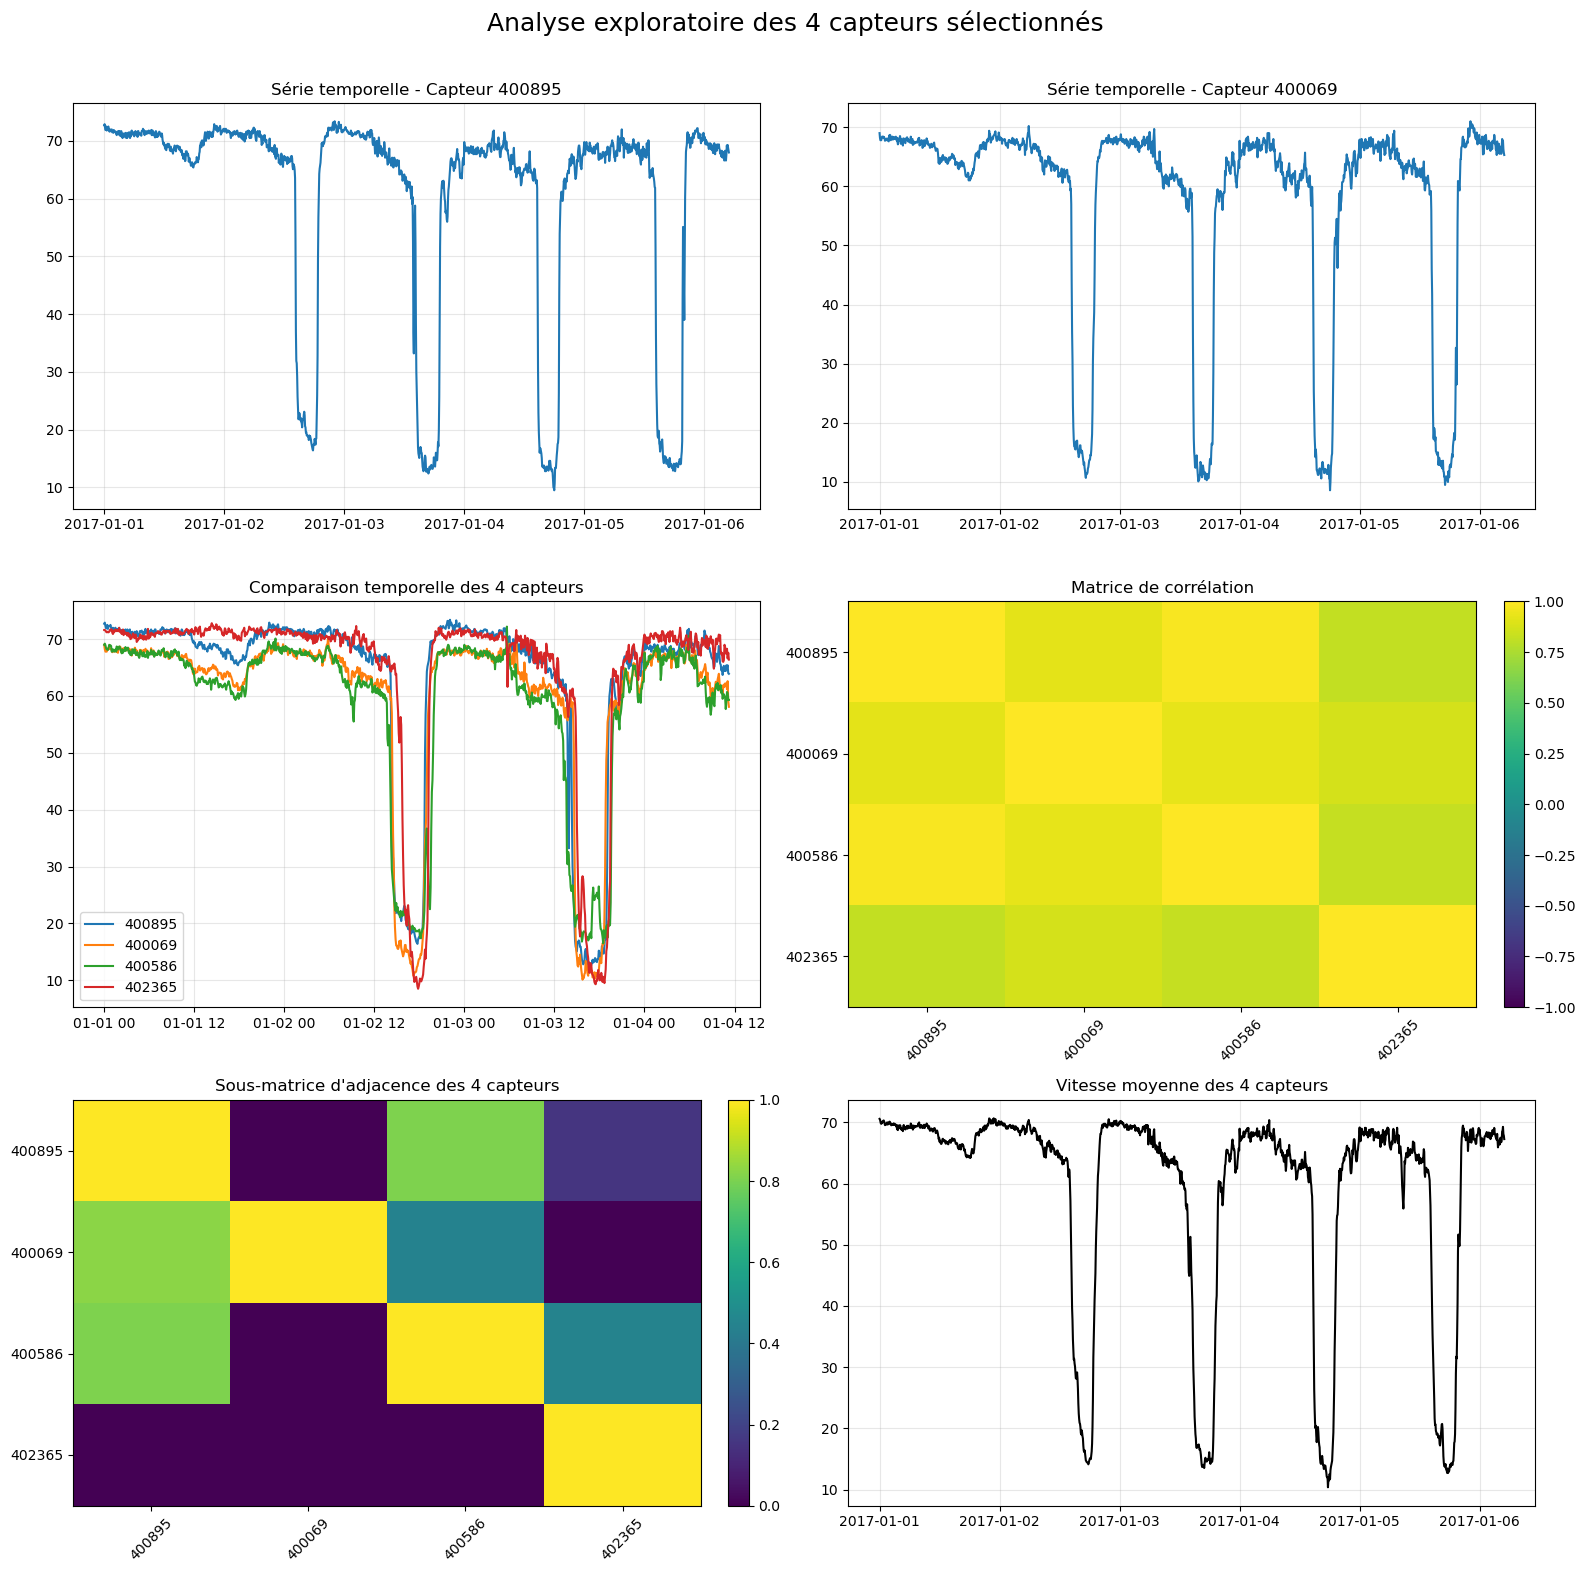

In [22]:
# ============================================================
# CELL 2 - VISUALISATIONS VARIEES POUR LE RAPPORT
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle("Analyse exploratoire des 4 capteurs sélectionnés", fontsize=18)

# 1) Série capteur 1
axes[0, 0].plot(df_sel[selected_sensors[0]].iloc[:1500])
axes[0, 0].set_title(f"Série temporelle - Capteur {selected_sensors[0]}")
axes[0, 0].grid(True, alpha=0.3)

# 2) Série capteur 2
axes[0, 1].plot(df_sel[selected_sensors[1]].iloc[:1500])
axes[0, 1].set_title(f"Série temporelle - Capteur {selected_sensors[1]}")
axes[0, 1].grid(True, alpha=0.3)

# 3) Les 4 capteurs sur la même figure
for s in selected_sensors:
    axes[1, 0].plot(df_sel[s].iloc[:1000], label=str(s))
axes[1, 0].set_title("Comparaison temporelle des 4 capteurs")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4) Heatmap corrélation
corr = df_sel.corr()
im1 = axes[1, 1].imshow(corr, vmin=-1, vmax=1, aspect="auto")
axes[1, 1].set_title("Matrice de corrélation")
axes[1, 1].set_xticks(range(len(selected_sensors)))
axes[1, 1].set_yticks(range(len(selected_sensors)))
axes[1, 1].set_xticklabels(selected_sensors, rotation=45)
axes[1, 1].set_yticklabels(selected_sensors)
fig.colorbar(im1, ax=axes[1, 1], fraction=0.046, pad=0.04)

# 5) Heatmap sous-adjacence
im2 = axes[2, 0].imshow(sub_adj, aspect="auto")
axes[2, 0].set_title("Sous-matrice d'adjacence des 4 capteurs")
axes[2, 0].set_xticks(range(len(selected_sensors)))
axes[2, 0].set_yticks(range(len(selected_sensors)))
axes[2, 0].set_xticklabels(selected_sensors, rotation=45)
axes[2, 0].set_yticklabels(selected_sensors)
fig.colorbar(im2, ax=axes[2, 0], fraction=0.046, pad=0.04)

# 6) Vitesse moyenne
axes[2, 1].plot(df_sel.mean(axis=1).iloc[:1500], color="black")
axes[2, 1].set_title("Vitesse moyenne des 4 capteurs")
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

ENTRAINEMENT DU GCN
Epoch 01/15 | Train Loss = 0.200618
Epoch 02/15 | Train Loss = 0.167989
Epoch 03/15 | Train Loss = 0.155563
Epoch 04/15 | Train Loss = 0.147425
Epoch 05/15 | Train Loss = 0.138108
Epoch 06/15 | Train Loss = 0.129736
Epoch 07/15 | Train Loss = 0.121301
Epoch 08/15 | Train Loss = 0.114742
Epoch 09/15 | Train Loss = 0.109671
Epoch 10/15 | Train Loss = 0.103292
Epoch 11/15 | Train Loss = 0.100647
Epoch 12/15 | Train Loss = 0.096072
Epoch 13/15 | Train Loss = 0.092855
Epoch 14/15 | Train Loss = 0.089196
Epoch 15/15 | Train Loss = 0.084609

RESULTATS GCN
GCN MAE  : 3.6259
GCN RMSE : 7.4051


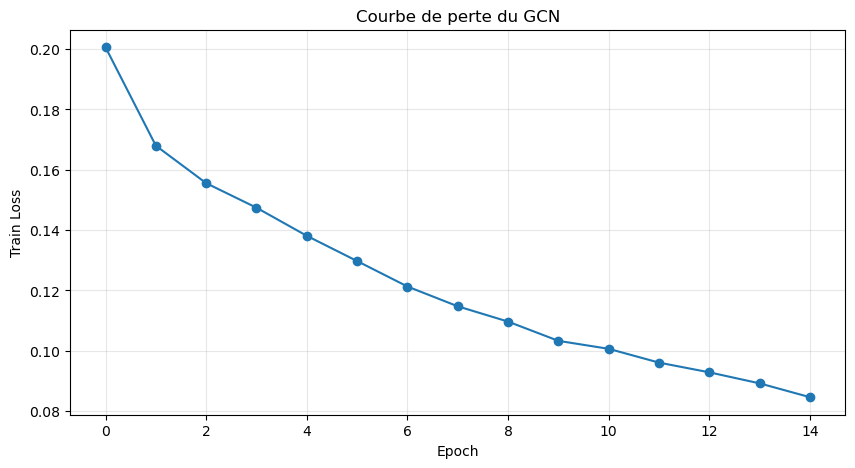

In [23]:
# ============================================================
# CELL 3 - MODELE GCN
# ============================================================

A_norm_tensor = torch.tensor(sub_adj_norm, dtype=torch.float32, device=device)

class SimpleGraphConv(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, A):
        # x : (batch, nodes, in_features)
        x = torch.matmul(A, x)        # diffusion spatiale
        x = self.linear(x)            # transformation
        return x

class GCNForecaster(nn.Module):
    def __init__(self, n_nodes, window, gcn_hidden=16):
        super().__init__()
        self.n_nodes = n_nodes
        self.window = window

        self.gconv1 = SimpleGraphConv(1, gcn_hidden)
        self.gconv2 = SimpleGraphConv(gcn_hidden, gcn_hidden)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(window * n_nodes * gcn_hidden, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_nodes)
        )

    def forward(self, x):
        # x : (batch, window, nodes)
        b, t, n = x.shape
        x = x.unsqueeze(-1)                       # (batch, window, nodes, 1)
        x = x.reshape(b * t, n, 1)               # (batch*window, nodes, 1)

        h = torch.relu(self.gconv1(x, A_norm_tensor))
        h = torch.relu(self.gconv2(h, A_norm_tensor))

        h = h.reshape(b, t, n, -1)               # (batch, window, nodes, hidden)
        out = self.fc(h)
        return out

gcn_model = GCNForecaster(n_nodes=n_sensors, window=WINDOW, gcn_hidden=16).to(device)

print("=" * 80)
print("ENTRAINEMENT DU GCN")
print("=" * 80)

gcn_losses = train_model(
    model=gcn_model,
    train_loader=train_loader,
    device=device,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

gcn_mae, gcn_rmse, gcn_true, gcn_pred = evaluate_model(
    gcn_model, test_loader, scaler, device, max_batches=MAX_TEST_BATCHES
)

print("\n" + "=" * 80)
print("RESULTATS GCN")
print("=" * 80)
print(f"GCN MAE  : {gcn_mae:.4f}")
print(f"GCN RMSE : {gcn_rmse:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(gcn_losses, marker="o")
plt.title("Courbe de perte du GCN")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.grid(True, alpha=0.3)
plt.show()

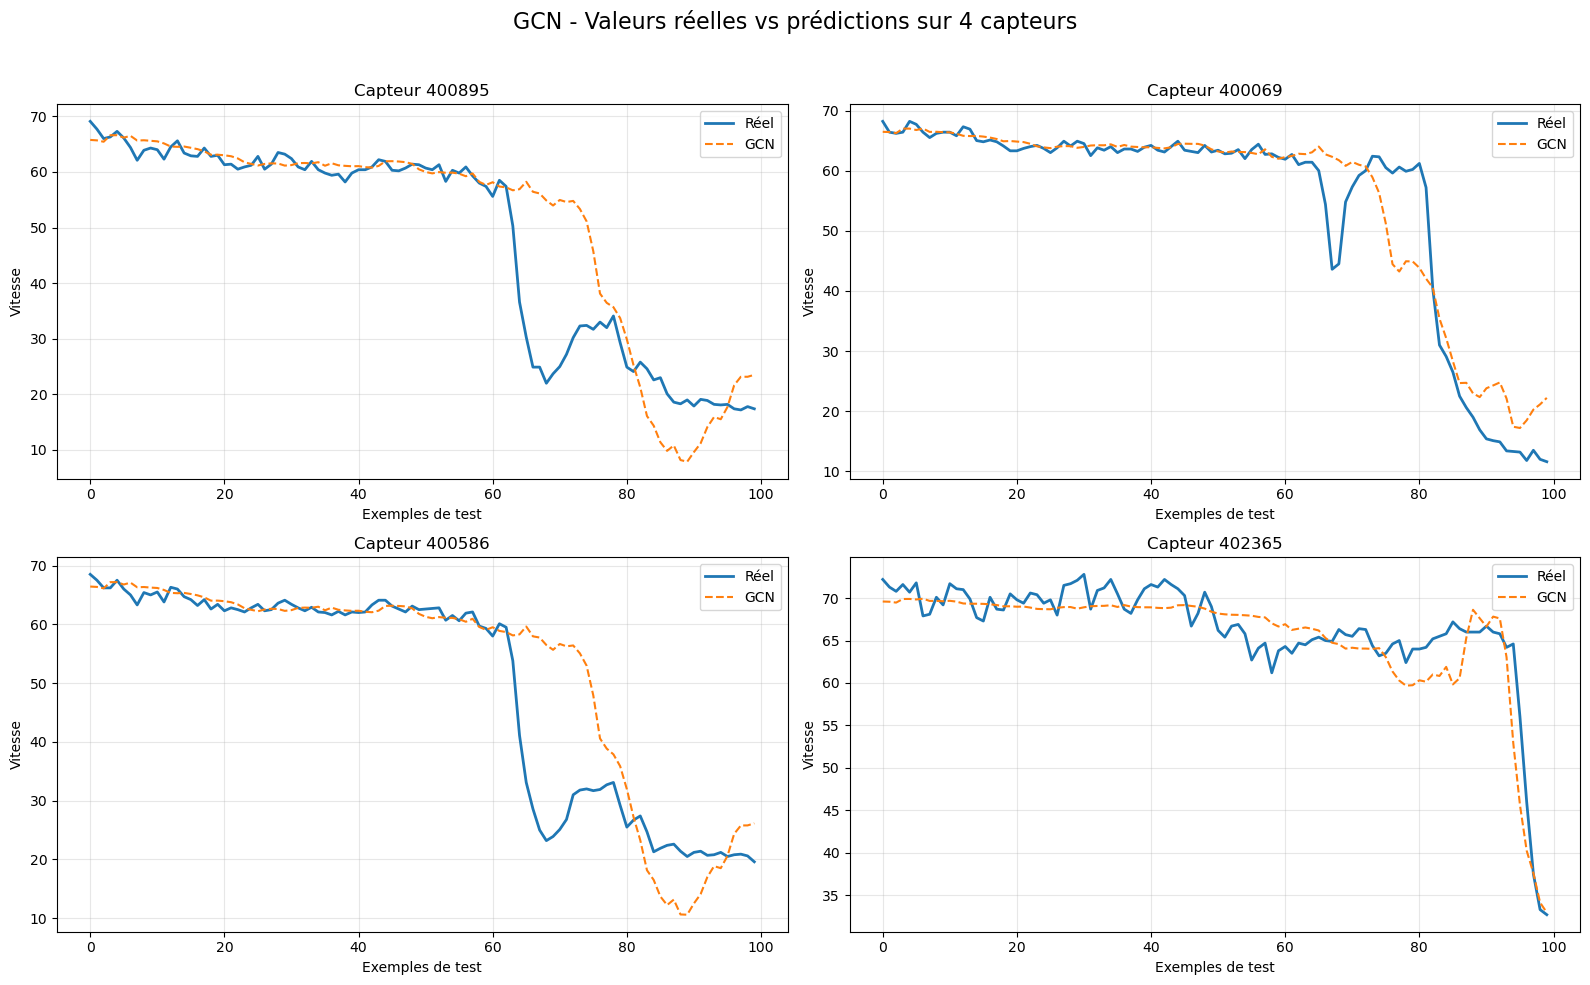

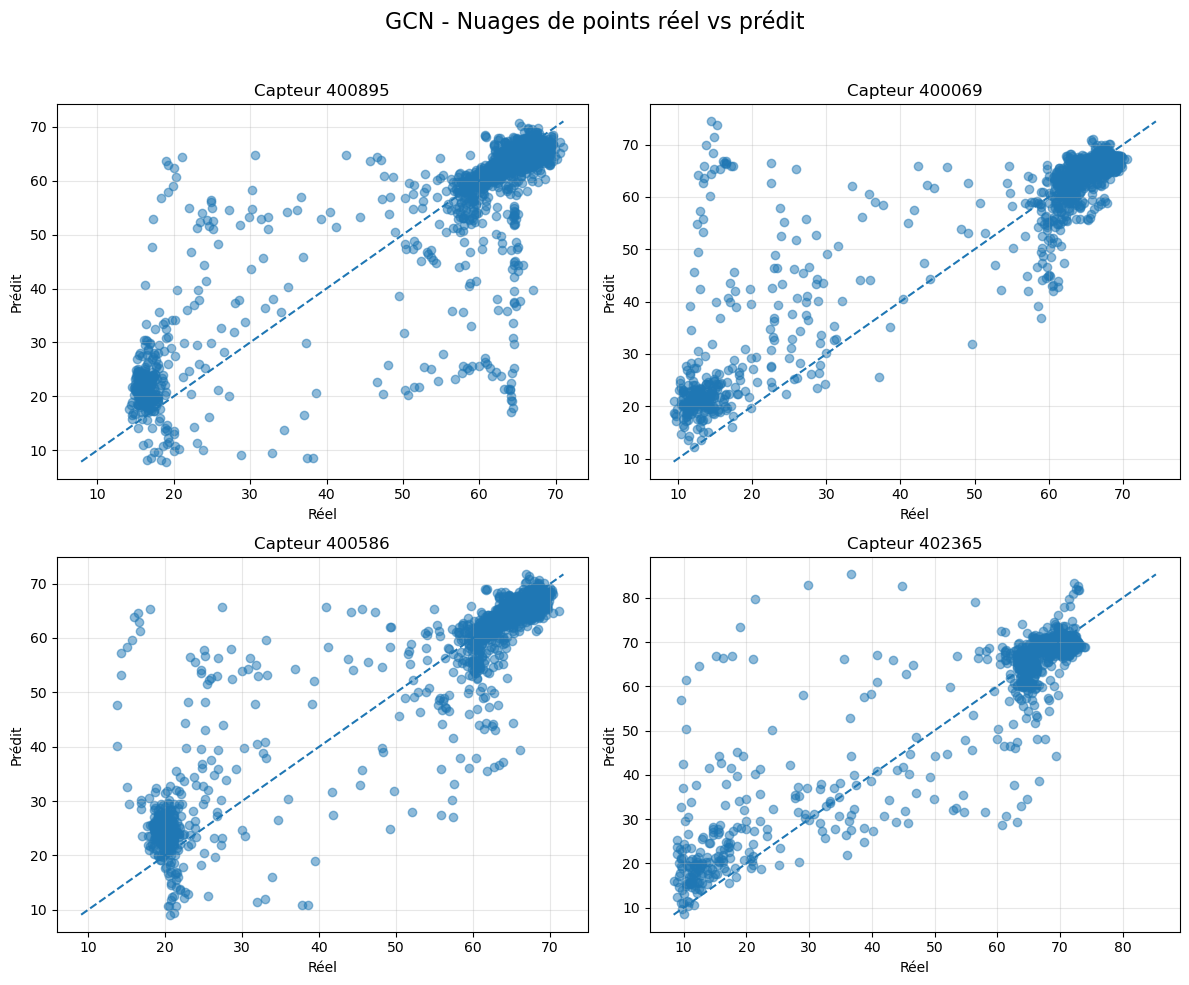

In [27]:
# ============================================================
# CELL 4 - GRAPHIQUES GCN SUR LES 4 CAPTEURS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("GCN - Valeurs réelles vs prédictions sur 4 capteurs", fontsize=16)

for i in range(4):
    ax = axes[i // 2, i % 2]
    ax.plot(gcn_true[:100, i], label="Réel", linewidth=2)
    ax.plot(gcn_pred[:100, i], label="GCN", linestyle="--")
    ax.set_title(f"Capteur {selected_sensors[i]}")
    ax.set_xlabel("Exemples de test")
    ax.set_ylabel("Vitesse")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Scatter réel vs prédit
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("GCN - Nuages de points réel vs prédit", fontsize=16)

for i in range(4):
    ax = axes[i // 2, i % 2]
    ax.scatter(gcn_true[:, i], gcn_pred[:, i], alpha=0.5)
    min_v = min(gcn_true[:, i].min(), gcn_pred[:, i].min())
    max_v = max(gcn_true[:, i].max(), gcn_pred[:, i].max())
    ax.plot([min_v, max_v], [min_v, max_v], linestyle="--")
    ax.set_title(f"Capteur {selected_sensors[i]}")
    ax.set_xlabel("Réel")
    ax.set_ylabel("Prédit")
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

ENTRAINEMENT DU LSTM
Epoch 01/15 | Train Loss = 0.239891
Epoch 02/15 | Train Loss = 0.192686
Epoch 03/15 | Train Loss = 0.177984
Epoch 04/15 | Train Loss = 0.169735
Epoch 05/15 | Train Loss = 0.161689
Epoch 06/15 | Train Loss = 0.156293
Epoch 07/15 | Train Loss = 0.149926
Epoch 08/15 | Train Loss = 0.147616
Epoch 09/15 | Train Loss = 0.139780
Epoch 10/15 | Train Loss = 0.133864
Epoch 11/15 | Train Loss = 0.129556
Epoch 12/15 | Train Loss = 0.122609
Epoch 13/15 | Train Loss = 0.111155
Epoch 14/15 | Train Loss = 0.107379
Epoch 15/15 | Train Loss = 0.102117

RESULTATS LSTM
LSTM MAE  : 3.4998
LSTM RMSE : 7.5089


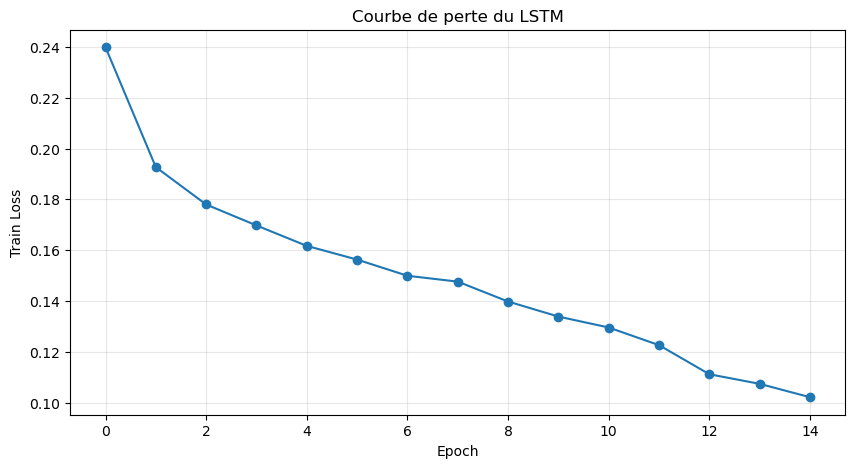

In [25]:
# ============================================================
# CELL 5 - MODELE LSTM SEUL
# ============================================================

class LSTMForecaster(nn.Module):
    def __init__(self, n_sensors, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_sensors,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_sensors)
        )

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_hidden = hn[-1]
        out = self.fc(last_hidden)
        return out

lstm_model = LSTMForecaster(n_sensors=n_sensors, hidden_size=64, num_layers=1).to(device)

print("=" * 80)
print("ENTRAINEMENT DU LSTM")
print("=" * 80)

lstm_losses = train_model(
    model=lstm_model,
    train_loader=train_loader,
    device=device,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

lstm_mae, lstm_rmse, lstm_true, lstm_pred = evaluate_model(
    lstm_model, test_loader, scaler, device, max_batches=MAX_TEST_BATCHES
)

print("\n" + "=" * 80)
print("RESULTATS LSTM")
print("=" * 80)
print(f"LSTM MAE  : {lstm_mae:.4f}")
print(f"LSTM RMSE : {lstm_rmse:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(lstm_losses, marker="o")
plt.title("Courbe de perte du LSTM")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.grid(True, alpha=0.3)
plt.show()

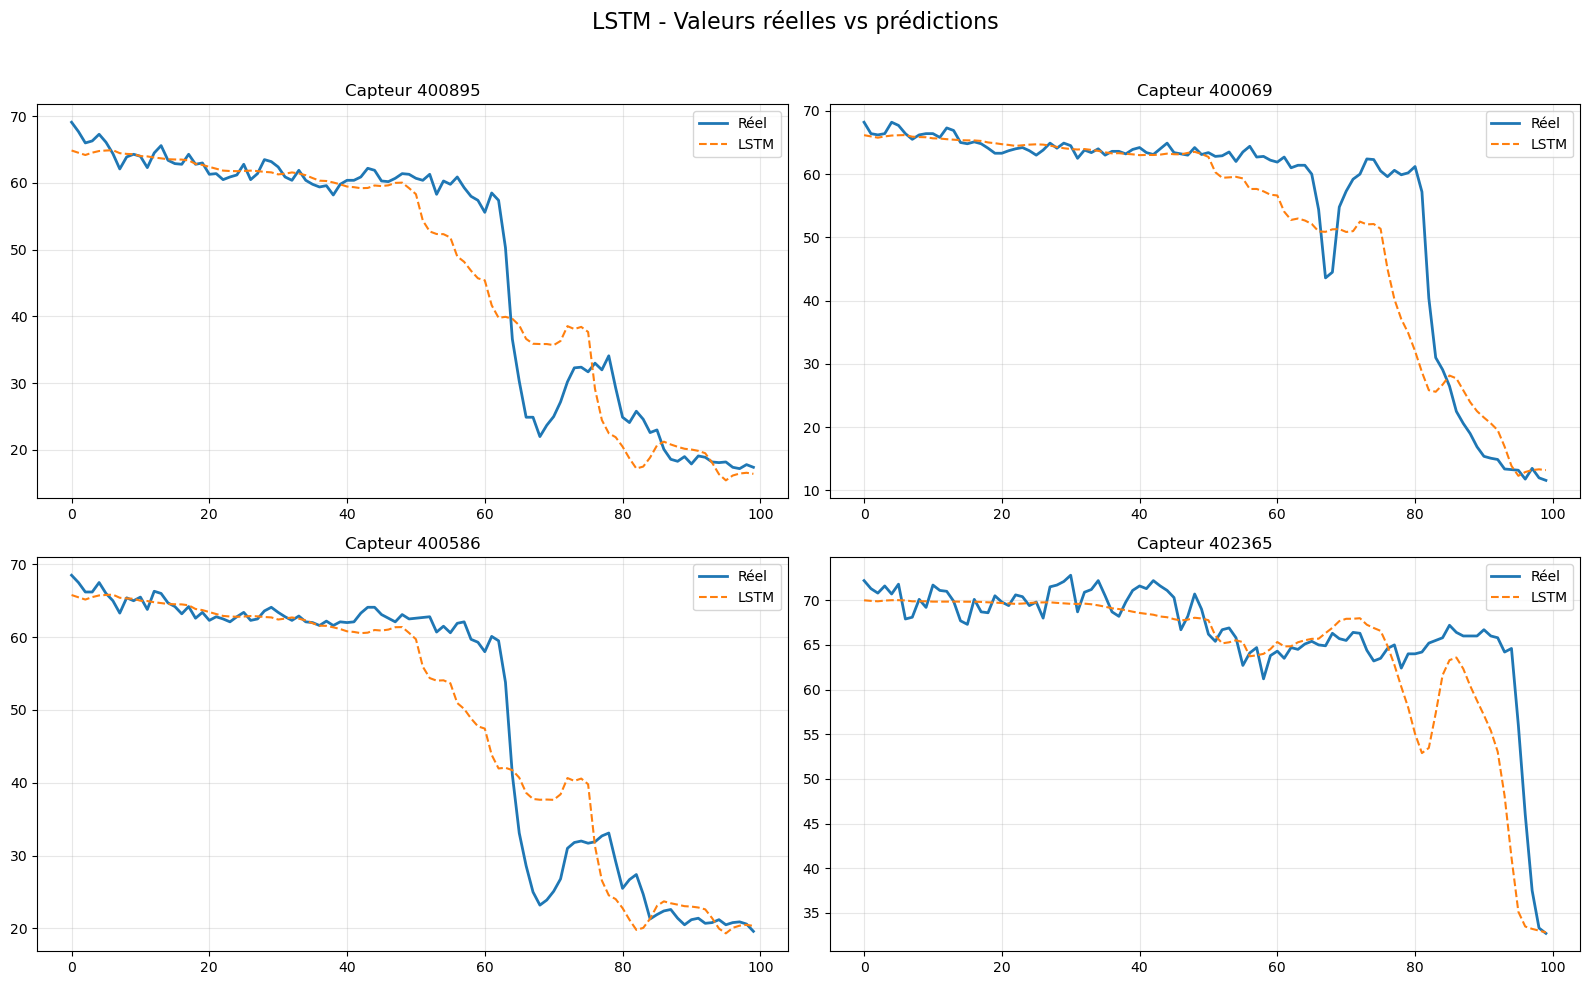

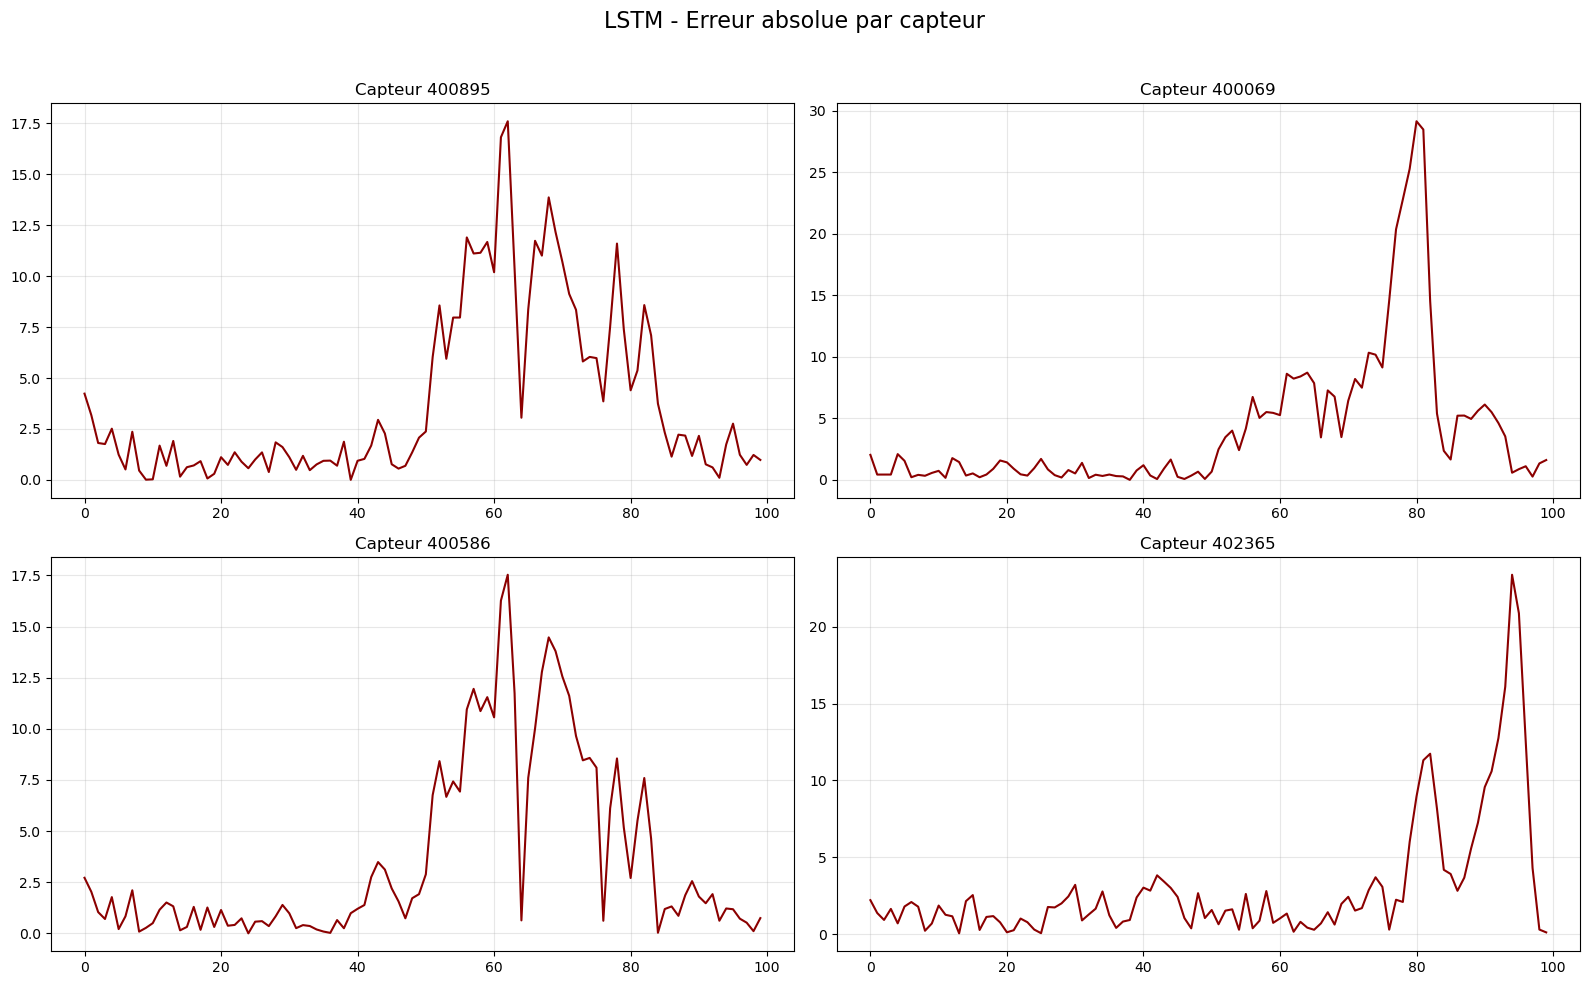

In [26]:
# ============================================================
# CELL 6 - 2 GRAPHIQUES LSTM
# ============================================================

# Graphique 1 : réel vs prédit sur les 4 capteurs
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("LSTM - Valeurs réelles vs prédictions", fontsize=16)

for i in range(4):
    ax = axes[i // 2, i % 2]
    ax.plot(lstm_true[:100, i], label="Réel", linewidth=2)
    ax.plot(lstm_pred[:100, i], label="LSTM", linestyle="--")
    ax.set_title(f"Capteur {selected_sensors[i]}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Graphique 2 : erreur absolue
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("LSTM - Erreur absolue par capteur", fontsize=16)

for i in range(4):
    ax = axes[i // 2, i % 2]
    abs_err = np.abs(lstm_true[:100, i] - lstm_pred[:100, i])
    ax.plot(abs_err, color="darkred")
    ax.set_title(f"Capteur {selected_sensors[i]}")
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

ENTRAINEMENT DU GCN + LSTM
Epoch 01/15 | Train Loss = 0.233676
Epoch 02/15 | Train Loss = 0.197293
Epoch 03/15 | Train Loss = 0.184014
Epoch 04/15 | Train Loss = 0.173040
Epoch 05/15 | Train Loss = 0.166542
Epoch 06/15 | Train Loss = 0.161849
Epoch 07/15 | Train Loss = 0.155117
Epoch 08/15 | Train Loss = 0.152007
Epoch 09/15 | Train Loss = 0.146545
Epoch 10/15 | Train Loss = 0.140845
Epoch 11/15 | Train Loss = 0.136363
Epoch 12/15 | Train Loss = 0.129354
Epoch 13/15 | Train Loss = 0.122835
Epoch 14/15 | Train Loss = 0.118974
Epoch 15/15 | Train Loss = 0.112961

RESULTATS GCN + LSTM
GCN+LSTM MAE  : 3.1437
GCN+LSTM RMSE : 6.2249


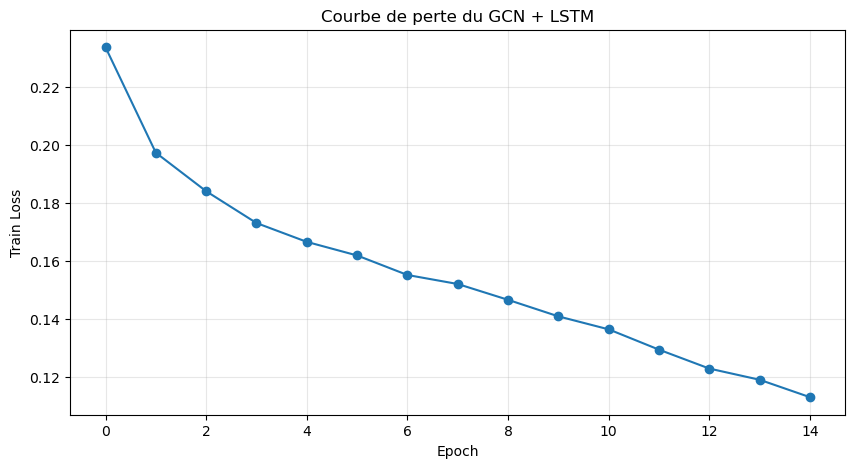

In [28]:
# ============================================================
# CELL 7 - MODELE HYBRIDE GCN + LSTM
# ============================================================

class GCNLSTMForecaster(nn.Module):
    def __init__(self, n_nodes, gcn_hidden=8, lstm_hidden=64):
        super().__init__()
        self.n_nodes = n_nodes
        self.gcn_hidden = gcn_hidden

        self.gconv1 = SimpleGraphConv(1, gcn_hidden)
        self.gconv2 = SimpleGraphConv(gcn_hidden, gcn_hidden)

        self.lstm = nn.LSTM(
            input_size=n_nodes * gcn_hidden,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_nodes)
        )

    def forward(self, x):
        # x : (batch, window, nodes)
        b, t, n = x.shape
        x = x.unsqueeze(-1)                     # (batch, window, nodes, 1)
        x = x.reshape(b * t, n, 1)

        h = torch.relu(self.gconv1(x, A_norm_tensor))
        h = torch.relu(self.gconv2(h, A_norm_tensor))

        h = h.reshape(b, t, n * self.gcn_hidden)
        out, (hn, cn) = self.lstm(h)
        last_hidden = hn[-1]
        out = self.fc(last_hidden)
        return out

gcn_lstm_model = GCNLSTMForecaster(n_nodes=n_sensors, gcn_hidden=8, lstm_hidden=64).to(device)

print("=" * 80)
print("ENTRAINEMENT DU GCN + LSTM")
print("=" * 80)

gcn_lstm_losses = train_model(
    model=gcn_lstm_model,
    train_loader=train_loader,
    device=device,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

gcn_lstm_mae, gcn_lstm_rmse, gcn_lstm_true, gcn_lstm_pred = evaluate_model(
    gcn_lstm_model, test_loader, scaler, device, max_batches=MAX_TEST_BATCHES
)

print("\n" + "=" * 80)
print("RESULTATS GCN + LSTM")
print("=" * 80)
print(f"GCN+LSTM MAE  : {gcn_lstm_mae:.4f}")
print(f"GCN+LSTM RMSE : {gcn_lstm_rmse:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(gcn_lstm_losses, marker="o")
plt.title("Courbe de perte du GCN + LSTM")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.grid(True, alpha=0.3)
plt.show()

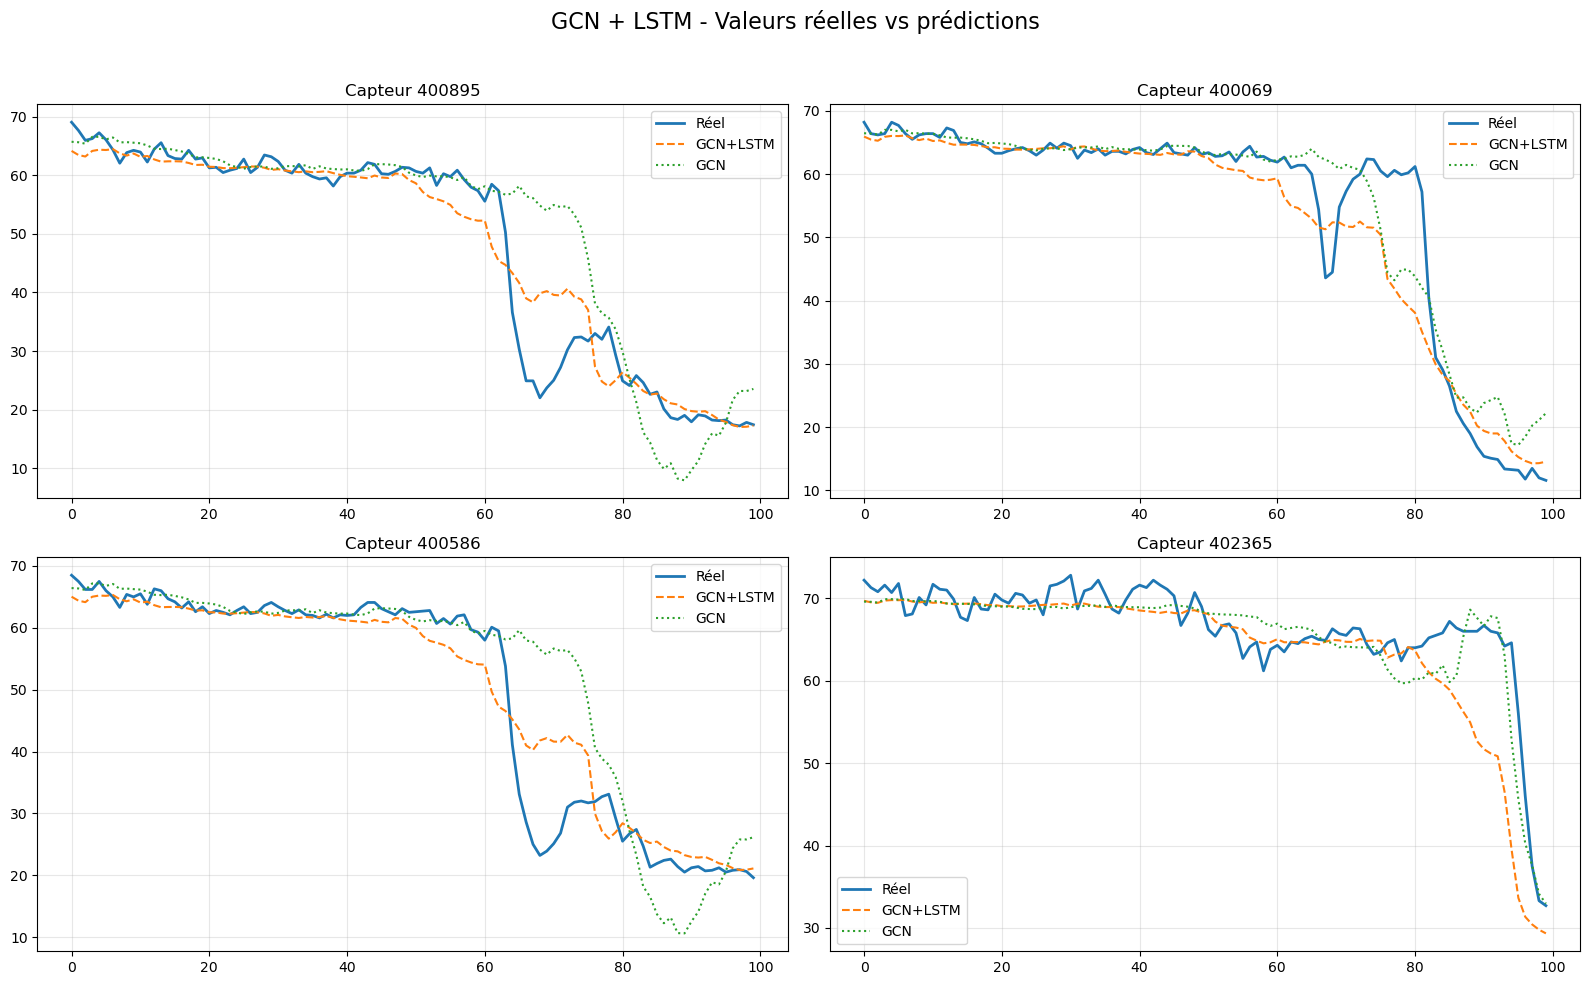

In [30]:
# ============================================================
# CELL 8 - GRAPHIQUES GCN + LSTM
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("GCN + LSTM - Valeurs réelles vs prédictions", fontsize=16)

for i in range(4):
    ax = axes[i // 2, i % 2]
    ax.plot(gcn_lstm_true[:100, i], label="Réel", linewidth=2)
    ax.plot(gcn_lstm_pred[:100, i], label="GCN+LSTM", linestyle="--")
    ax.plot(gcn_pred[:100, i], label="GCN", linestyle=":")
    ax.set_title(f"Capteur {selected_sensors[i]}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()